In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('Data_Train_Outliers_Removed.csv')

In [3]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Price',
       'Journey_Day', 'Journey_Month', 'Journey_Weekday', 'Journey_DayOfWeek',
       'Is_Weekend', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour',
       'Arrival_Minute', 'Duration_Minutes', 'Number_of_Airports',
       'Journey_Quarter'],
      dtype='object')

# 1. Feature Encoding

### Without the Column Transformer 

In [4]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

#Separating the features and the targets from the dataframe
X=df.drop('Price', axis=1)
y=df['Price']

# ------------------------------
# One_Hot Encoding
# ------------------------------

onehot_cols = ['Airline','Source','Destination','Route']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_data = ohe.fit_transform(X[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_data,
    columns = ohe.get_feature_names_out(onehot_cols),
    index = X.index
)

# Removing the original columns
X = X.drop(columns=onehot_cols)

# Add original columns
X = pd.concat([X, encoded_df], axis=1)

# ------------------------------
# Ordinal Encoding
# ------------------------------

weekday_order = [[
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]]

oe = OrdinalEncoder(categories = weekday_order)

X['Journey_Weekday'] = oe.fit_transform(X[['Journey_Weekday']])

# Finally Encoded Dataset
#X.head()
X.columns

Index(['Total_Stops', 'Journey_Day', 'Journey_Month', 'Journey_Weekday',
       'Journey_DayOfWeek', 'Is_Weekend', 'Dep_Hour', 'Dep_Minute',
       'Arrival_Hour', 'Arrival_Minute',
       ...
       'Route_DEL → LKO → BOM → COK', 'Route_DEL → LKO → COK',
       'Route_DEL → MAA → BOM → COK', 'Route_DEL → MAA → COK',
       'Route_DEL → NAG → BOM → COK', 'Route_DEL → PNQ → COK',
       'Route_DEL → RPR → NAG → BOM → COK', 'Route_DEL → TRV → COK',
       'Route_DEL → UDR → BOM → COK', 'Route_MAA → CCU'],
      dtype='object', length=163)

 ### Note: To avoid repeated assigning of the names, I just inverted the case of the variables used in the second code

### With the Column Transformer

In [5]:
from sklearn.compose import ColumnTransformer

x = df.drop('Price', axis = 1)
Y =  df['Price']

# Grouping Columns
ohe_cols = ['Airline','Destination','Source', 'Route']
ord_cols = ['Journey_Weekday'] 

# Order of weekdays
Weekday_order = [[
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]]

# Column Transformer

preprocessor = ColumnTransformer(
    transformers = [
                ('Onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
                ('Ordinal', OrdinalEncoder(categories=Weekday_order), ord_cols)
    ], remainder='passthrough'
)

# Transform the data
x_encoded = preprocessor.fit_transform(x)

# Getting the features name
features_name = preprocessor.get_feature_names_out()

# Turning into dataframe
x_encoded = pd.DataFrame(
    x_encoded,
    columns = features_name,
    index = x.index
)

x_encoded.head()

,Onehot__Airline_Air Asia,Onehot__Airline_Air India,Onehot__Airline_GoAir,Onehot__Airline_IndiGo,Onehot__Airline_Jet Airways,Onehot__Airline_Jet Airways Business,Onehot__Airline_Multiple carriers,Onehot__Airline_Multiple carriers Premium economy,Onehot__Airline_SpiceJet,Onehot__Airline_Trujet,...,remainder__Journey_Month,remainder__Journey_DayOfWeek,remainder__Is_Weekend,remainder__Dep_Hour,remainder__Dep_Minute,remainder__Arrival_Hour,remainder__Arrival_Minute,remainder__Duration_Minutes,remainder__Number_of_Airports,remainder__Journey_Quarter
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,6.0,1.0,22.0,20.0,1.0,10.0,170.0,2.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,2.0,0.0,5.0,50.0,13.0,15.0,445.0,4.0,2.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.0,6.0,1.0,9.0,25.0,4.0,25.0,1140.0,4.0,2.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,6.0,1.0,18.0,5.0,23.0,30.0,325.0,3.0,2.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,0.0,16.0,50.0,21.0,35.0,285.0,3.0,1.0


# 2. Feature Scaling

### Selecting  the columns that needs to be changed

In [6]:
# numeric_cols = X.select_dtypes(include="int64").columns

numeric_cols = ['Total_Stops', 'Journey_Day', 'Journey_Month', 'Journey_DayOfWeek',
                'Dep_Hour', 'Dep_Minute', 'Arrival_Hour',
           'Arrival_Minute', 'Duration_Minutes', 'Number_of_Airports']

## Visualizing before scaling

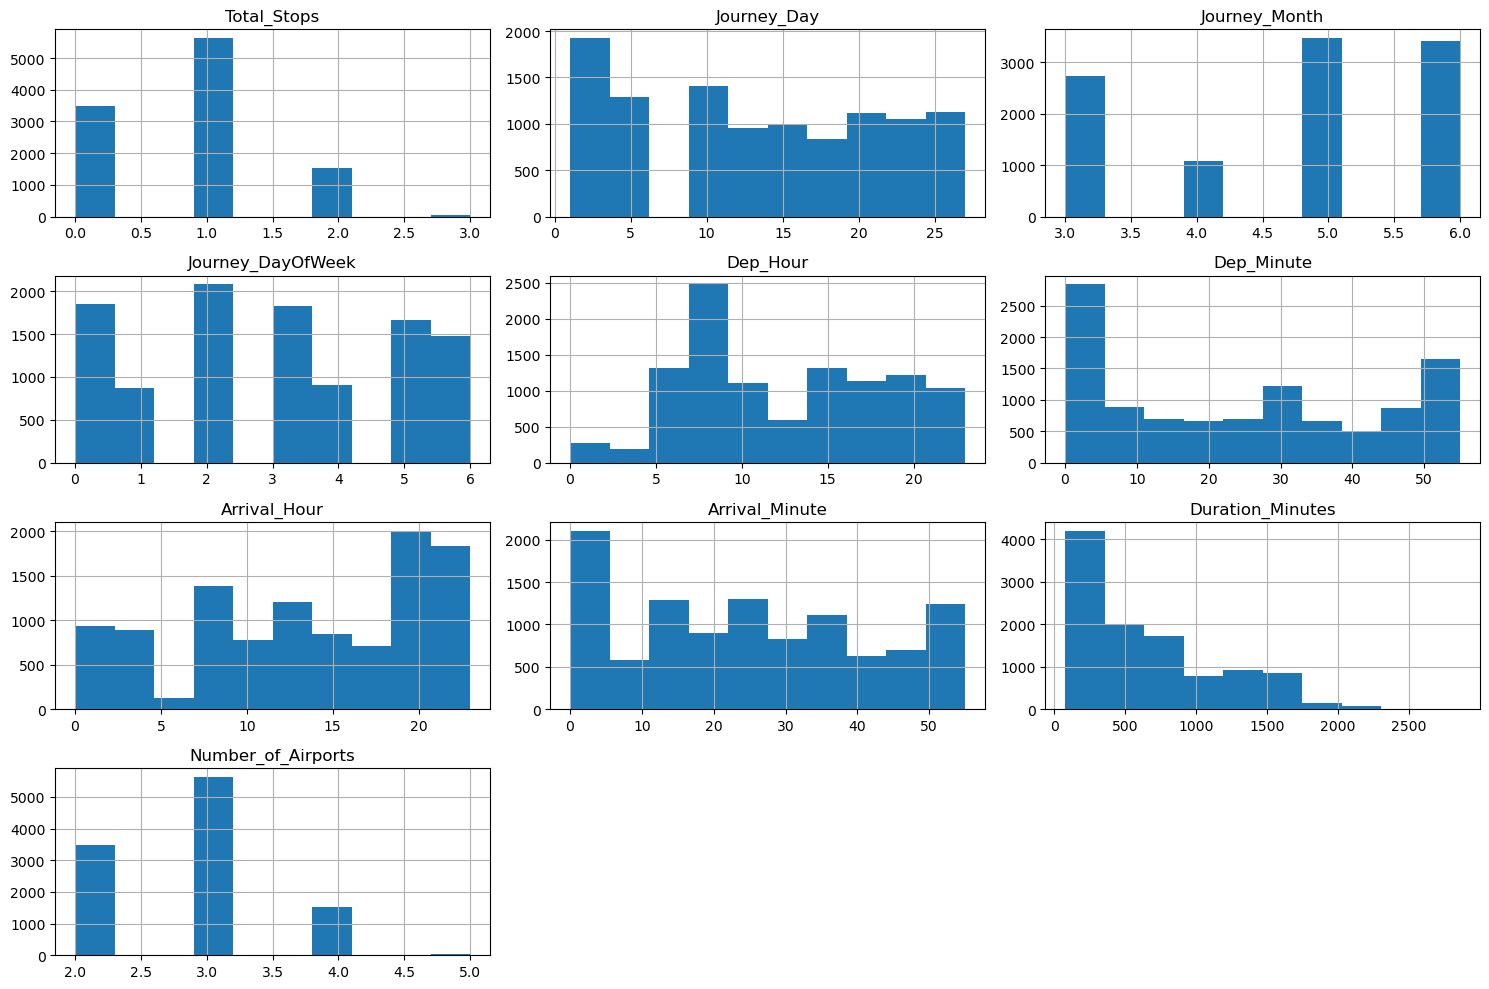

In [7]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Visualizing the values before scaling
import matplotlib.pyplot as plt

X[numeric_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()


### Implementing Preprocessing

In [8]:
# Now, scaling the features using standardization
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

### Checking whether the features are scaled or not!

In [9]:
X_scaled[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Stops,10680.0,-4.657115e-17,1.000047,-1.221388,-1.221388,0.261270,0.261270,3.226585
Journey_Day,10680.0,7.517915e-17,1.000047,-1.475595,-0.885874,-0.178208,0.883290,1.590955
Journey_Month,10680.0,2.701127e-16,1.000047,-1.467836,-1.467836,0.250041,1.108980,1.108980
Journey_DayOfWeek,10680.0,-5.921189e-17,1.000047,-1.462702,-0.964356,0.032337,1.029029,1.527375
Dep_Hour,10680.0,-9.114640e-17,1.000047,-2.172970,-0.781310,-0.259438,0.958265,1.828052
Dep_Minute,10680.0,6.985673e-17,1.000047,-1.300504,-1.034056,0.031734,0.831077,1.630420
Arrival_Hour,10680.0,4.956501e-17,1.000047,-1.946068,-0.779811,0.094881,0.823792,1.406920
Arrival_Minute,10680.0,-7.983626e-18,1.000047,-1.495809,-0.889929,0.018891,0.624771,1.836532
Duration_Minutes,10680.0,3.259981e-17,1.000047,-1.118723,-0.931604,-0.242220,0.565345,4.366808
Number_of_Airports,10680.0,3.532755e-16,1.000047,-1.221388,-1.221388,0.261270,0.261270,3.226585


### Visualizing after scaling!

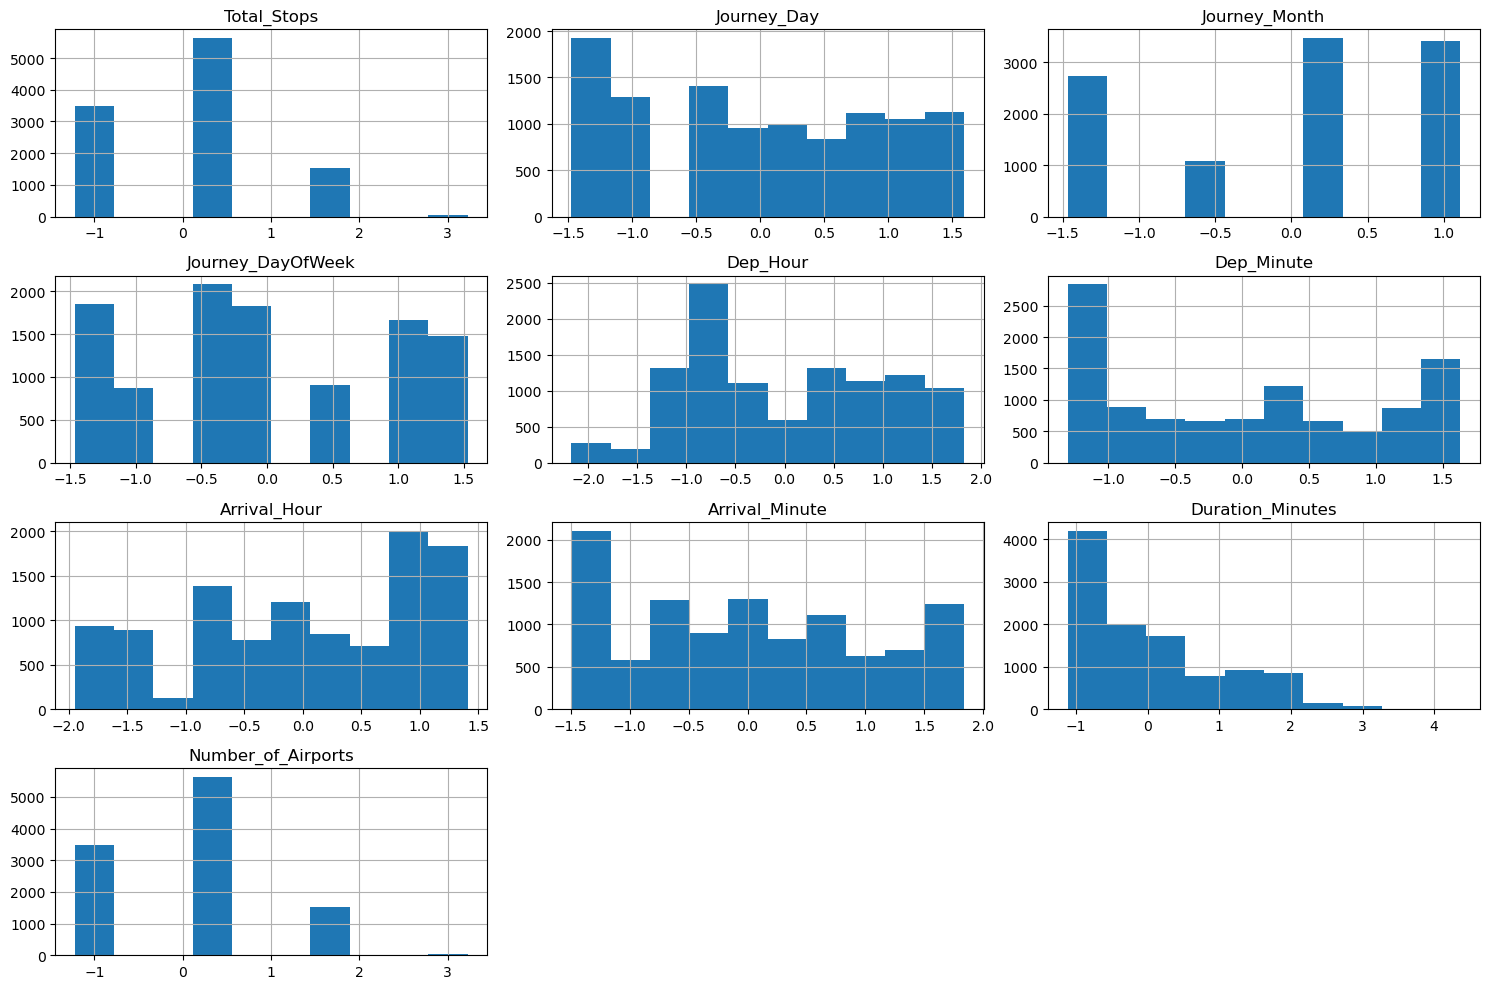

In [10]:
X_scaled[numeric_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

# 3.Feature Selection

In [15]:
df.corr(numeric_only=True)["Price"].sort_values().round(4)

Journey_Quarter      -0.2008
Journey_Day          -0.1534
Journey_Month        -0.1032
Arrival_Minute       -0.0865
Dep_Minute           -0.0249
Dep_Hour              0.0069
Is_Weekend            0.0205
Arrival_Hour          0.0242
Journey_DayOfWeek     0.0516
Duration_Minutes      0.5066
Number_of_Airports    0.6037
Price                 1.0000
Name: Price, dtype: float64

In [13]:
df[["Total_Stops", "Number_of_Airports"]].corr()

,Total_Stops,Number_of_Airports
Total_Stops,1.0,1.0
Number_of_Airports,1.0,1.0


In [14]:
df.drop(columns=["Total_Stops"], inplace=True)

#### Correlation Summary (Feature Selection Perspective)

- Correlation measures the strength and direction of the linear relationship between a feature and the target variable.
- The correlation coefficient ranges from -1 to +1.
- A value close to +1 indicates a strong positive linear relationship.
- A value close to -1 indicates a strong negative linear relationship.
- A value close to 0 indicates a weak or no linear relationship.
- High correlation generally suggests that the feature is useful for linear models.
- Low correlation does not mean the feature is useless; it may still have a nonlinear relationship with the target or be important when combined with other features.
- Features with low correlation should be investigated, not immediately dropped.
- Before dropping a low-correlation feature, check:
    - Whether it makes sense from domain knowledge.
    - Whether it is redundant with another feature.
    - Whether feature importance or statistical tests also indicate it is unimportant.
    - Whether removing it improves model performance (R², MAE, RMSE, etc.).
- The final decision to keep or remove a feature should always be based on model performance and domain knowledge, not on correlation alone.

In [11]:
# Coverting everything into a new csv file

processed_df = X_scaled.copy()
processed_df["Price"] = y

processed_df.to_csv(
    "Data_Train_Feature_Scaled.csv",
    index=False
)

'# Coverting everything into a new csv file\n\nprocessed_df = X_scaled.copy()\nprocessed_df["Price"] = y\n\nprocessed_df.to_csv(\n    "Data_Train_Feature_Scaled.csv",\n    index=False\n)'